# Export GeoTIFF
This example will walk through exporting a GeoTIFF for an AOI made up of a single polygon, and also demonstrate the additional step needed to export a GeoTIFF from a MultiPolygon AOI. 

### Import required packages and set up Cecil client.

In [1]:
import xarray as xr
import rioxarray as rxr
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
import os 
import json
import folium
import cecil

client = cecil.Client()

## Single Polygon AOIs
---

### Pull data of interest.
In the SQL query below, replace the reprojection_id with your own, and make sure that the database and variable names are correct for the data you're pulling.

In [2]:
df = client.query('''
    SELECT
        year,
        x,
        y,
        aboveground_live_carbon_density,                            
        canopy_cover,
        canopy_height                                              
    FROM
        planet.forest_carbon_diligence                              -- Specify the database to pull from. 
    WHERE
        reprojection_id = '558c2826-8cc7-475e-b80a-ca943368e0eb'    -- Insert your reprojection ID here.
''')

# Examine dataframe structure.
df.head(5)

,year,x,y,aboveground_live_carbon_density,canopy_cover,canopy_height
0,2013,132.535967,-12.721198,10.0,16.0,2.0
1,2013,132.529717,-12.721948,12.0,29.0,1.0
2,2013,132.537717,-12.722448,3.0,3.0,0.0
3,2013,132.540217,-12.722698,3.0,5.0,0.0
4,2013,132.530217,-12.723198,17.0,35.0,2.0


### Export as GeoTIFF.
[XArray](https://docs.xarray.dev/en/stable/) is widely used for handling NetCDF data structures, but is also useful for working with other forms of multi-layered raster data. With the [rioxarray](https://corteva.github.io/rioxarray/stable/) extension, it is possible to read and write GeoTIFFs and perform geospatial operations within the XArray format.

The following function works to export a single-band GeoTIFF for a specified variable and year of interest. Make sure to change the CRS and output path to be suited for your own use-case. 

In [3]:
def export_geotiff(df, var, year, out_dir):
    """Export a single-band geotiff with a variable and year of interest."""

    # Ensure that the data types of the x, y, and variable of interest are numeric.
    df[['y', 'x', var]] = df[['y', 'x', var]].apply(pd.to_numeric, errors='coerce')

    # Set dataframe indices before converting to xarray and renaming dimensions for use with rioxarray.
    data_df = df.set_index(['year','y', 'x'])
    data_xarr = data_df.to_xarray()

    # Assign CRS of the dataset (e.g. WGS84 (EPSG:4326)).
    data_xarr = data_xarr.rio.write_crs("EPSG:4326", inplace=True) # Change to the appropriate CRS for your data.

    # Define output path based on the variable and year of interest.
    out_path = os.path.join(out_dir, "planet", "forest_carbon_diligence", var, f"{year}.tif")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # Subset the data to just the year and variable of interest before exporting as GeoTIFF.
    data_xarr.sel(year=[year])[var].rio.to_raster(out_path)
    print(f'Exported GeoTIFF to: {out_path}')
    
    return

Now choose some variables of interest, years of interest, define an output directory, and export your GeoTIFFs.

In [4]:
# Select variables of interest from the dataframe.
vars_of_interest = ['aboveground_live_carbon_density', 'canopy_cover', 'canopy_height']

# Select one or more years to export GeoTIFFs for. 
years_of_interest = [2015, 2020, 2023]

# Define the output directory where the GeoTIFFs will be exported.
out_dir = 'outputs-single'

# Loop through the years of interest to export GeoTIFFs for each.
for year in years_of_interest:
    for var in vars_of_interest:
        export_geotiff(df, var, year, out_dir)

Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/aboveground_live_carbon_density/2015.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/canopy_cover/2015.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/canopy_height/2015.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/aboveground_live_carbon_density/2020.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/canopy_cover/2020.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/canopy_height/2020.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/aboveground_live_carbon_density/2023.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/canopy_cover/2023.tif
Exported GeoTIFF to: outputs-single/planet/forest_carbon_diligence/canopy_height/2023.tif


## MultiPolygon AOIs
---
If your AOI is composed of more than one disconnected polygons, there will only be data returned for the areas within the polygons. The following code block visualizes a MultiPolygon AOI that we will use for demonstration within the original single Polygon AOI. 

You can change the AOI IDs to your own to visualize your own AOIs in this way, or just move on to creating the regular grid of values and exporting the GeoTIFF.

In [5]:
# Load the AOIs from the Cecil platform
aoi_single = client.get_aoi("7dbbf7c3-0447-45a7-8849-e031c6099c1c") # Change to your own AOI ID
aoi_single = aoi_single.geometry
aoi_multi = client.get_aoi("c5431392-679b-4926-b36e-9b5ed01de3ce") # Change to your own AOI ID
aoi_multi = aoi_multi.geometry

# Initialize map at the centroid of the AOI.
centroid = shape(aoi_single).centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=16, control_scale=True, tiles=None)

# Add satellite layer as the default background.
satellite = folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    name='Esri Satellite Imagery',
    attr='Esri',
    overlay=False,
    show=True  
).add_to(m)

# Add the GeoJSON data to the map (both the MultiPolygon and single Polygon AOI).
folium.GeoJson(aoi_multi, name="AOI Boundary - MultiPolygon").add_to(m)
folium.GeoJson(aoi_single, name="AOI Boundary - Single Polygon").add_to(m)

# Display the map
m

### Pull data of interest.
In the SQL query below, replace the reprojection_id with your own, and make sure that the database and variable names are correct for the data you're pulling.

In [6]:
df_multi = client.query('''
    SELECT
        year,
        x,
        y,
        aboveground_live_carbon_density,                            
        canopy_cover,
        canopy_height                                              
    FROM
        planet.forest_carbon_diligence                              -- Specify the database to pull from. 
    WHERE
        reprojection_id = '43ad88f4-2b22-4278-8c4a-6f8a24dbc1c2'    -- Insert your reprojection ID here.
''')

# Examine dataframe structure.
df_multi.head(5)

,year,x,y,aboveground_live_carbon_density,canopy_cover,canopy_height
0,2022,132.532493,-12.728247,6.0,7.0,0.0
1,2013,132.534493,-12.722497,8.0,12.0,1.0
2,2017,132.530743,-12.727747,0.0,0.0,0.0
3,2018,132.531993,-12.728247,0.0,0.0,0.0
4,2017,132.530743,-12.727497,NaN,NaN,NaN


If we visualize the data in this dataframe, we will see that it is a discontinuous grid. When pulled directly from the Cecil platform, there are no rows for the areas between the polygons. Because raster data formats expect a regularly spaced grid of values, this data cannot be directly exported as a GeoTIFF. We first need to fill in the gaps between these polygons to create a regular gridded dataset. 

Number of pixels in MultiPolygon dataframe: 1760


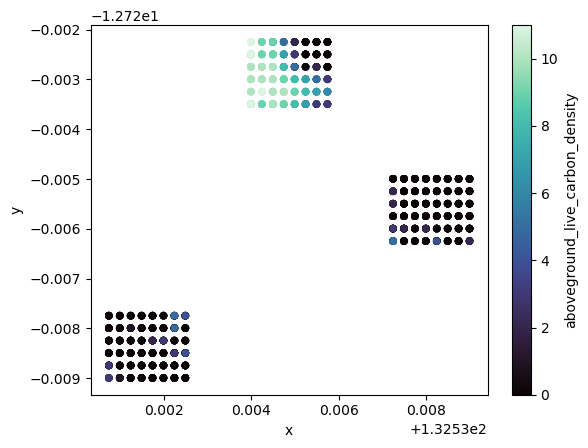

In [7]:
df_multi.plot(x='x', y='y', kind='scatter', c='aboveground_live_carbon_density', cmap='mako')
print(f"Number of pixels in MultiPolygon dataframe: {df_multi.shape[0]}")

To fill in the spaces between the polygons, we can use the following function called `complete_df()`. This function creates a regular grid based on the min and max extents of the polygons and the resolution of the dataset. It then fills in any spaces between the valid data with NoData values.

In [8]:
def complete_df(df, resolution, time_col='year'):
    """
    Complete a DataFrame by converting to xarray and aligning with a regular grid.
    """
    # Convert input dataframe to xarray.
    data_df = df.set_index([time_col, 'y', 'x'])
    data_xarr = data_df.to_xarray()
    
    # Get the coordinates of the input dataframe.
    x_coords = data_xarr.x.values
    y_coords = data_xarr.y.values
    time_coords = data_xarr[time_col].values 
    
    # Create a regular grid based on the min, max and resolution of the input dataset.
    x_reg = np.arange(x_coords.min(), x_coords.max() + resolution, resolution)
    y_reg = np.arange(y_coords.min(), y_coords.max() + resolution, resolution)

    # Create a new xarray with the full regular grid of coordinates.
    grid_xarr = xr.Dataset(coords={"x": x_reg, "y": y_reg, time_col: time_coords})

    # Use reindex_like() to align the input dataframe to the regular grid (setting tolerance based on resolution).
    data_xarr_reindexed = data_xarr.reindex_like(grid_xarr, method="nearest", tolerance=resolution/2)

    # Convert back to dataframe.
    completed_df = data_xarr_reindexed.to_dataframe().reset_index()
    
    return completed_df

Now we can specify the resolution of our dataset and run the function to create the regular grid. Also double check that the time_col parameter matches your date (i.e. if your dataset uses 'date' instead of 'year' for the time variable, replace it before running the function.)

In [9]:
# Complete the DataFrame to fill out a regular grid with the specified resolution (should match the data).
resolution = 0.00025 # Change to match the resolution of your data.
completed_df = complete_df(df_multi, resolution, time_col='year')

To check that the function worked, we can visualize the data again and check the number of pixels. We should see that the number of pixels is now much higher than before, but the data should still look almost identical when plotted. This is because the dataframe has been filled with NoData rows to create the full regular grid.

Number of pixels in completed dataframe: 10472


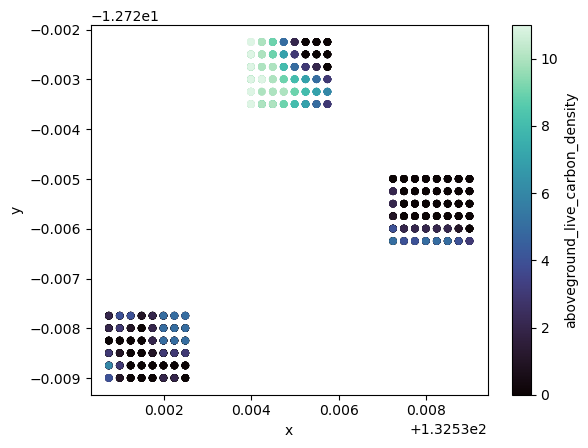

In [10]:
completed_df.plot(x='x', y='y', kind='scatter', c='aboveground_live_carbon_density', cmap='mako')
print(f"Number of pixels in completed dataframe: {completed_df.shape[0]}")

### Export as GeoTIFF.
Now that we have filled in the dataframe, we can export the data as a GeoTIFF using the same function that we used previously for the single polygon AOI.

In [11]:
# Select variables of interest from the dataframe.
vars_of_interest = ['aboveground_live_carbon_density', 'canopy_cover', 'canopy_height']

# Select one or more years to export GeoTIFFs for. 
years_of_interest = [2015, 2020, 2023]

# Define the output directory where the GeoTIFFs will be exported.
out_dir = 'outputs-multi'

# Loop through the years of interest to export GeoTIFFs for each.
for year in years_of_interest:
    for var in vars_of_interest:
        export_geotiff(completed_df, var, year, out_dir)

Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/aboveground_live_carbon_density/2015.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/canopy_cover/2015.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/canopy_height/2015.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/aboveground_live_carbon_density/2020.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/canopy_cover/2020.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/canopy_height/2020.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/aboveground_live_carbon_density/2023.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/canopy_cover/2023.tif
Exported GeoTIFF to: outputs-multi/planet/forest_carbon_diligence/canopy_height/2023.tif


## Plot and Verify GeoTIFFs.
---
Now we can load the GeoTIFFs for the single polygon AOI and the MultiPolygon AOI to compare and verify that they look as expected.

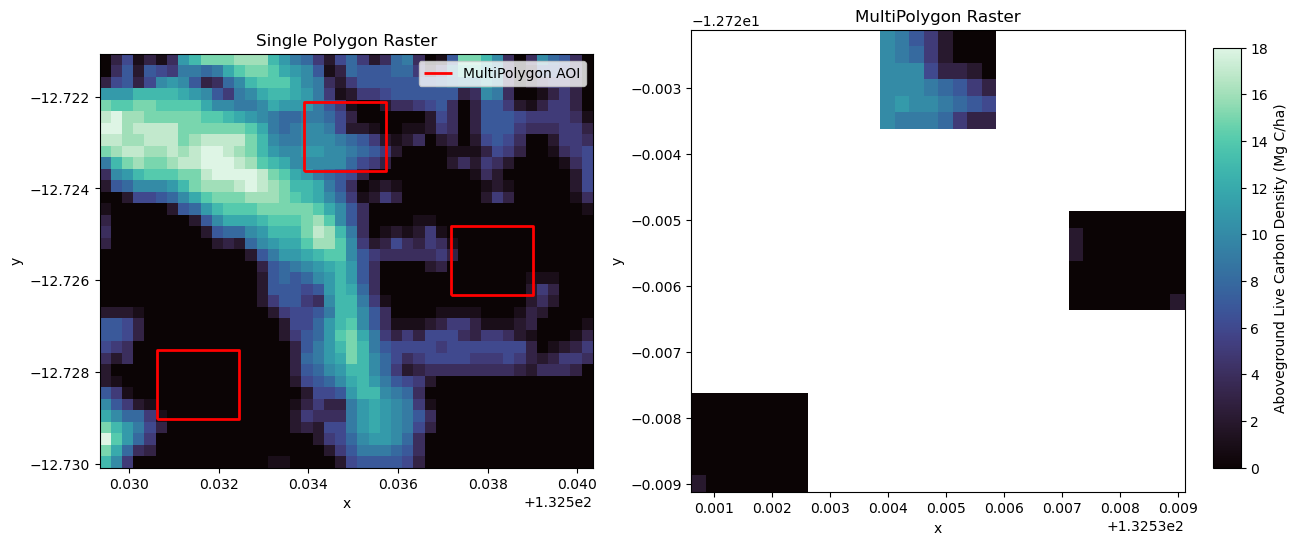

In [12]:
# Load the rasters for comparison.
test_single = rxr.open_rasterio('outputs-single/planet/forest_carbon_diligence/aboveground_live_carbon_density/2015.tif')
test_multi = rxr.open_rasterio('outputs-multi/planet/forest_carbon_diligence/aboveground_live_carbon_density/2015.tif')

# Define min and max for consistent coloring.
vmin = test_single.min()  
vmax = test_single.max()

# Create a figure with two subplots side by side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the single polygon raster on the first subplot.
test_single.plot(cmap='mako', vmin=vmin, vmax=vmax, ax=ax1, add_colorbar=False)
ax1.set_title('Single Polygon Raster')

# Get the MultiPolygon AOI and plot its boundary.
aoi_multi = client.get_aoi("c5431392-679b-4926-b36e-9b5ed01de3ce") # Change to your own AOI ID.
aoi_multi_geometry = shape(aoi_multi.geometry)
multi_gdf = gpd.GeoDataFrame(geometry=[aoi_multi_geometry], crs="EPSG:4326")
multi_gdf.boundary.plot(ax=ax1, color='red', linewidth=2, label='MultiPolygon AOI')
ax1.legend(loc='upper right')

# Plot the MultiPolygon raster on the second subplot.
test_multi.plot(cmap='mako', vmin=vmin, vmax=vmax, ax=ax2, add_colorbar=False)
ax2.set_title('MultiPolygon Raster')

# Add a colorbar that applies to both plots.
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='mako', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Aboveground Live Carbon Density (Mg C/ha)')

plt.show()